In [177]:
 import pandas as pd

In [178]:
import numpy as np

In [179]:
import matplotlib.pyplot as plt

In [180]:
import seaborn as sns

In [181]:
from sklearn.preprocessing import StandardScaler

In [182]:
import tensorflow as tf

In [183]:
from tensorflow.keras.models import Sequential

In [184]:
from tensorflow.keras.layers import Input,Flatten,Dense

In [185]:
df=pd.read_csv(r"C:\Users\91918\OneDrive\Desktop\Deep_Learning\datasets\concrete_data.csv")

In [186]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


NaNs

In [187]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

<Axes: >

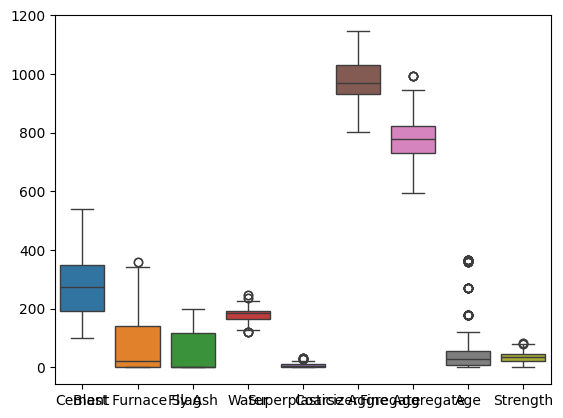

In [188]:
sns.boxplot(df)

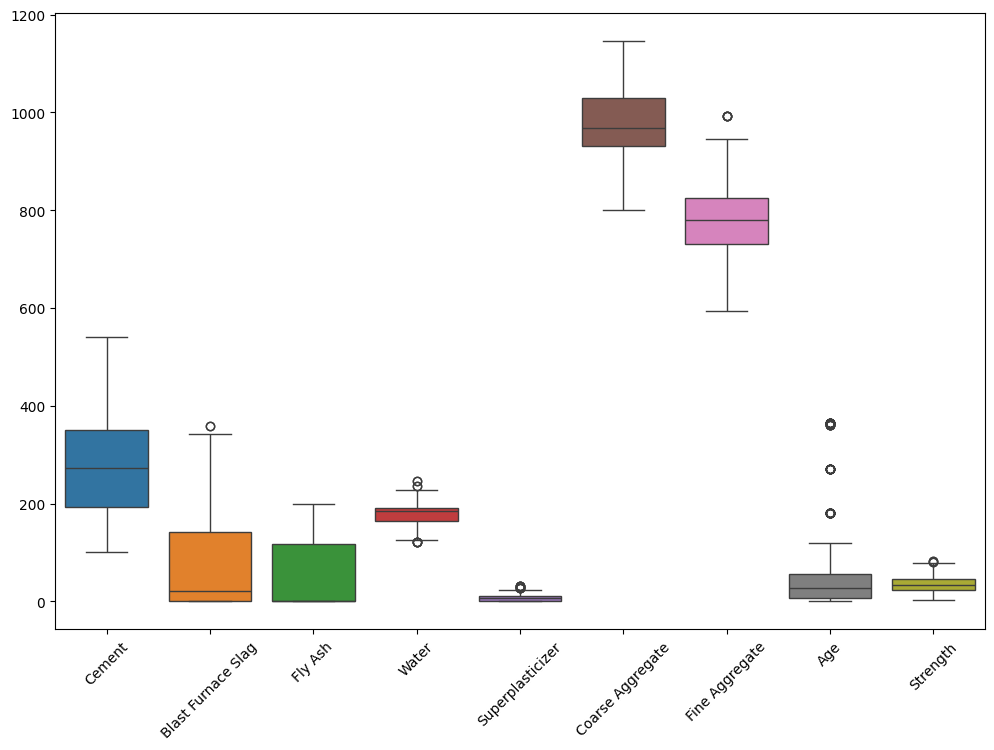

In [189]:
plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

In [190]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [191]:
cols=['Blast Furnace Slag','Water','Superplasticizer','Fine Aggregate']

In [192]:
cols

['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate']

In [193]:
for c in cols:
    print(c)

Blast Furnace Slag
Water
Superplasticizer
Fine Aggregate


In [194]:
for c in cols:
    q1=df[c].quantile(0.25)
    q3=df[c].quantile(0.75)
    iqr=q3-q1
    lower=q1-(1.5*iqr)
    upper=q3+(1.5*iqr)
    df[c]=df[c].map(lambda x:lower if x<lower else upper if x>upper else x)

<Axes: >

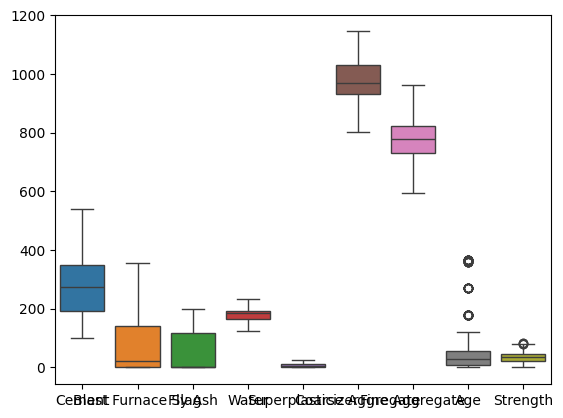

In [195]:
sns.boxplot(df)

In [196]:
q1_age=df["Age"].quantile(0.25)

In [197]:
q3_age=df["Age"].quantile(0.75)

In [198]:
iqr_age=q3_age-q1_age

In [199]:
lower_age=q3_age-(1.5*iqr_age)

In [200]:
upper_age=q3_age+(1.5*iqr_age)

In [201]:
lower_age

np.float64(-17.5)

In [202]:
upper_age

np.float64(129.5)

In [203]:
df["Age"]=df["Age"].map(lambda x: lower_age if x <lower_age else upper_age if x>upper_age else x)

In [204]:
df["Age"]

0        28.0
1        28.0
2       129.5
3       129.5
4       129.5
        ...  
1025     28.0
1026     28.0
1027     28.0
1028     28.0
1029     28.0
Name: Age, Length: 1030, dtype: float64

In [205]:
df[df["Age"]<lower_age]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength


In [206]:
df[df["Age"]<upper_age]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90.0,47.03
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28.0,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28.0,45.85
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28.0,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0,32.77


In [207]:
df[df["Age"]<lower_age].count()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [208]:
df[df["Age"]>upper_age].count()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

<Axes: >

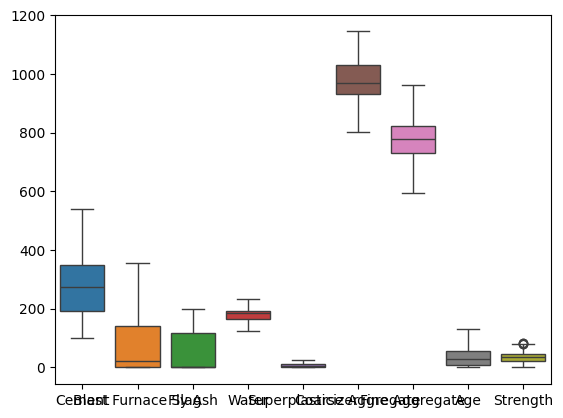

In [209]:
sns.boxplot(df)

Data Seperation

In [210]:
df.drop("Strength",axis=1)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,129.5
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28.0
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0


In [211]:
X=df.drop("Strength",axis=1)

In [212]:
y=df["Strength"]

In [213]:
X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,129.5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,129.5
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28.0
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0


In [215]:
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64

DATA SPLITTING

In [219]:
from sklearn.model_selection import train_test_split

In [221]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [222]:
X.shape

(1030, 8)

In [224]:
X_train.shape

(824, 8)

In [225]:
X_test.shape

(206, 8)

SCALING

In [227]:
from sklearn.preprocessing import StandardScaler

In [229]:
ss=StandardScaler()

In [230]:
ss

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [233]:
ss.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [238]:
X_train_ss=ss.transform(X_train)

In [239]:
X_test_ss=ss.transform(X_test)

In [240]:
X_train_ss

array([[-1.16087734,  0.85760247,  0.9824489 , ..., -0.25746155,
        -0.64866051, -0.27964442],
       [ 1.30862304, -0.60254668,  1.23259821, ..., -1.92694961,
        -0.27261827, -0.27964442],
       [-0.0768653 , -0.85568522,  1.06687429, ...,  1.01785948,
         0.06867419, -0.98804026],
       ...,
       [-0.86591441, -0.85568522,  1.12628475, ...,  1.34082214,
         0.33426177,  1.76053561],
       [ 1.78316909,  0.51126292, -0.83113361, ..., -1.54422615,
         0.11831673, -0.27964442],
       [ 0.28509237, -0.85568522,  0.9355459 , ..., -0.6172979 ,
         0.13693268, -0.27964442]], shape=(824, 8))

In [241]:
X_test_ss

array([[-0.1615392 ,  0.45603269, -0.83113361, ..., -0.52829244,
        -1.26546906,  2.59644271],
       [ 0.73730683,  1.319005  , -0.83113361, ..., -0.36681111,
        -0.20063659, -0.87469693],
       [ 0.99132853,  1.319005  , -0.83113361, ..., -0.36681111,
        -0.20063659, -0.27964442],
       ...,
       [ 0.02734873,  1.45592994, -0.83113361, ...,  0.39482129,
         0.39383282, -0.87469693],
       [ 1.30862304, -0.60254668,  1.23259821, ..., -1.92694961,
        -0.27261827,  0.51375893],
       [ 0.51771297, -0.85568522, -0.83113361, ..., -0.07055009,
         0.11211141,  1.47717727]], shape=(206, 8))

In [246]:
X_train.shape

(824, 8)

MODEL

In [259]:
from tensorflow.keras.models import Sequential

In [260]:
from tensorflow.keras.layers import Dense

In [261]:
smodel=Sequential()

In [262]:
smodel.add(Dense(64,activation="relu",input_shape=(X_train.shape[1],)))

In [263]:
smodel.add(Dense(32,activation="relu"))

In [264]:
smodel.compile(optimizer="adam",loss="mean_squared_error")

In [265]:
smodel.fit(X_train_ss,y_train,epochs=30,validation_split=0.2,verbose=0)

In [268]:
smodel.evaluate(X_test_ss,y_test)          #here 122 is mean squared error(100-11(evaluation))=89 is the accuracy

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 122.3061 


122.30612182617188

In [267]:
np.sqrt(122.30)

np.float64(11.058933040759403)